In [1]:
import sys
import os

sys.path.append(os.path.abspath(".."))

import pandas as pd
from src.ft_engineering import feature_engineering

In [2]:
df = pd.read_excel("../data/raw/Base_de_datos.xlsx")

df.head()

,tipo_credito,fecha_prestamo,capital_prestado,plazo_meses,edad_cliente,tipo_laboral,salario_cliente,total_otros_prestamos,cuota_pactada,puntaje,...,saldo_mora,saldo_total,saldo_principal,saldo_mora_codeudor,creditos_sectorFinanciero,creditos_sectorCooperativo,creditos_sectorReal,promedio_ingresos_datacredito,tendencia_ingresos,Pago_atiempo
0,7,2024-12-21 11:31:35,3692160.0,10,42,Independiente,8000000,2500000,341296,88.768094,...,0.0,51258.0,51258.0,0.0,5,0,0,908526.0,Estable,1
1,4,2025-04-22 09:47:35,840000.0,6,60,Empleado,3000000,2000000,124876,95.227787,...,0.0,8673.0,8673.0,0.0,0,0,2,939017.0,Creciente,1
2,9,2026-01-08 12:22:40,5974028.4,10,36,Independiente,4036000,829000,529554,47.613894,...,0.0,18702.0,18702.0,0.0,3,0,0,NaN,NaN,0
3,4,2025-08-04 12:04:10,1671240.0,6,48,Empleado,1524547,498000,252420,95.227787,...,0.0,15782.0,15782.0,0.0,3,0,0,1536193.0,Creciente,1
4,9,2025-04-26 11:24:26,2781636.0,11,44,Empleado,5000000,4000000,217037,95.227787,...,0.0,204804.0,204804.0,0.0,3,0,1,933473.0,Creciente,1


In [3]:
X_train, X_test, y_train, y_test = feature_engineering(df)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (8610, 68)
Test shape: (2153, 68)


# 1. Funciones reutilizables

In [4]:
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

def build_model(model, X_train, y_train):
    model.fit(X_train, y_train)
    return model


def summarize_classification(model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    accuracy = accuracy_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_proba)

    print("Accuracy:", accuracy)
    print("ROC AUC:", roc)
    print("\nClassification Report:\n")
    print(classification_report(y_test, y_pred))

    return accuracy, roc

# 2. Definir modelos

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

# 3. Entrenar y evaluar

In [6]:
results = {}

for name, model in models.items():
    print(f"\n===== {name} =====")
    trained_model = build_model(model, X_train, y_train)
    accuracy, roc = summarize_classification(trained_model, X_test, y_test)
    results[name] = {"Accuracy": accuracy, "ROC AUC": roc}


===== Logistic Regression =====
Accuracy: 0.9986065954482118
ROC AUC: 0.9999713195858547

Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.98      0.99       102
           1       1.00      1.00      1.00      2051

    accuracy                           1.00      2153
   macro avg       0.99      0.99      0.99      2153
weighted avg       1.00      1.00      1.00      2153


===== Random Forest =====
Accuracy: 1.0
ROC AUC: 1.0

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       102
           1       1.00      1.00      1.00      2051

    accuracy                           1.00      2153
   macro avg       1.00      1.00      1.00      2153
weighted avg       1.00      1.00      1.00      2153


===== Gradient Boosting =====
Accuracy: 1.0
ROC AUC: 1.0

Classification Report:

              precision    recall  f1-score   support

           0  

# 4. Tabla resumen

In [7]:
import pandas as pd

results_df = pd.DataFrame(results).T
results_df.sort_values(by="ROC AUC", ascending=False)

,Accuracy,ROC AUC
Random Forest,1.000000,1.000000
Gradient Boosting,1.000000,1.000000
Logistic Regression,0.998607,0.999971


# 5. Gráfico comparativo

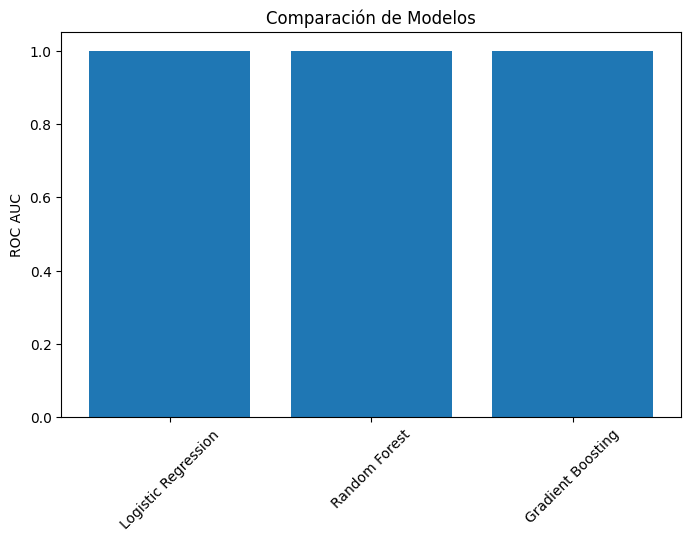

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.bar(results_df.index, results_df["ROC AUC"])
plt.ylabel("ROC AUC")
plt.title("Comparación de Modelos")
plt.xticks(rotation=45)
plt.show()